In [1]:
# 1. استدعاء المكتبات البرمجية اللازمة للتحليل والإحصاء
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 2. قراءة ملف البيانات النظيف
df = pd.read_csv('price_clean.csv')

# 3. عرض الأسطر الخمسة الأولى للتأكد من قراءة البيانات بنجاح
df.head()

,obj_regio1,obj_newlyConst,obj_yearConstructed,obj_firingTypes,obj_cellar,obj_houseNumber,obj_livingSpace,geo_krs,obj_condition,obj_street,geo_plz,obj_noRooms,obj_telekomInternetProductAvailable,obj_barrierFree,obj_regio3,obj_livingSpaceRange,obj_telekomUploadSpeed,obj_telekomDownloadSpeed,obj_purchasePrice,obj_purchasePrice_per_qm
0,Niedersachsen,n,2013.0,gas,n,NaN,170.0,Verden_Kreis,well_kept,NaN,28832.0,6.0,True,n,Achim,5.0,40.0,100.0,549000.0,3229.411765
1,Niedersachsen,n,1909.0,oil,n,NaN,170.0,Hannover_Kreis,well_kept,NaN,30900.0,6.0,True,n,Wedemark,5.0,2.4,16.0,460000.0,2705.882353
2,Niedersachsen,n,1969.0,district_heating,y,NaN,116.0,Celle_Kreis,well_kept,NaN,29353.0,6.0,True,n,other,2.0,10.0,50.0,148500.0,1280.172414
3,Niedersachsen,y,2020.0,NaN,n,NaN,133.0,Helmstedt_Kreis,first_time_use,NaN,38364.0,4.0,True,n,Schöningen,3.0,40.0,100.0,248400.0,1867.669173
4,Niedersachsen,n,2000.0,district_heating,y,NaN,136.0,Wolfsburg,well_kept,NaN,38446.0,5.0,True,y,other,3.0,2.4,16.0,369000.0,2713.235294


In [2]:
import pandas as pd

# 1. قراءة البيانات
df = pd.read_csv('price_clean.csv')

# 2. تحسين مخرج الإحصاء الوصفي للأرقام (تنظيف الفواصل وتقريبها)
print("==================================================")
print("   1. SUMMARY STATISTICS FOR NUMERICAL VARIABLES  ")
print("==================================================")
# غيّرنا أسماء الأعمدة لتكون احترافية في الطباعة
numerical_cols = {
    'obj_purchasePrice': 'Price (€)', 
    'obj_livingSpace': 'Living Space (m²)', 
    'obj_noRooms': 'Rooms'
}
summary = df[list(numerical_cols.keys())].describe().round(1)
summary.rename(columns=numerical_cols, inplace=True)
print(summary.loc[['mean', '50%', 'std', 'min', 'max']]) # اخترنا الأهم فقط لتقليل التشتت

print("\n==================================================")
print("   2. PERCENTAGE OF PROPERTY CONDITIONS          ")
print("==================================================")
# حساب النسبة المئوية وإضافة رمز % للشكل الجمالي
condition_pct = (df['obj_condition'].value_counts(normalize=True) * 100).round(1)
condition_df = pd.DataFrame({'Percentage': condition_pct.astype(str) + '%'})
print(condition_df)

   1. SUMMARY STATISTICS FOR NUMERICAL VARIABLES  
      Price (€)  Living Space (m²)  Rooms
mean   356673.3              193.6    6.6
50%    304903.0              161.0    6.0
std    252100.1              121.2    3.5
min     25000.0               30.0    1.0
max   3752000.0             2940.0   53.0

   2. PERCENTAGE OF PROPERTY CONDITIONS          
                                   Percentage
obj_condition                                
well_kept                               49.5%
need_of_renovation                      11.4%
first_time_use                          11.2%
mint_condition                          10.7%
modernized                               8.7%
refurbished                              3.6%
fully_renovated                          3.5%
first_time_use_after_refurbishment       0.8%
negotiable                               0.4%
ripe_for_demolition                      0.2%


In [3]:
import pandas as pd

# قراءة البيانات
df = pd.read_csv('price_clean.csv')

print("==================================================")
print("   1. TEMPORAL VARIABLE (Year Constructed)        ")
print("==================================================")
# استخدام الوسيط والقيم الصغرى والعظمى بدلاً من المتوسط
year_stats = df['obj_yearConstructed'].describe().loc[['50%', 'min', 'max']]
print(f"Median Year Built: {year_stats['50%']}")
print(f"Oldest Property:   {year_stats['min']}")
print(f"Newest Property:   {year_stats['max']}\n")

print("==================================================")
print("   2. DERIVED VARIABLE (Price per m²)            ")
print("==================================================")
# حساب متوسط وسيط سعر المتر المربع لأهميته في السوق
price_per_qm_stats = df['obj_purchasePrice_per_qm'].describe().loc[['mean', '50%']].round(2)
print(price_per_qm_stats)

print("\n==================================================")
print("   3. TECHNICAL VARIABLES (Internet Speeds)       ")
print("==================================================")
# حساب الإحصاءات مع إظهار عدد القيم المفقودة لكل عمود
internet_summary = df[['obj_telekomUploadSpeed', 'obj_telekomDownloadSpeed']].describe().round(1)
print(internet_summary.loc[['mean', '50%', 'count']])
print(f"Missing Upload Values: {df['obj_telekomUploadSpeed'].isna().sum()}")

   1. TEMPORAL VARIABLE (Year Constructed)        
Median Year Built: 1974.0
Oldest Property:   1496.0
Newest Property:   2021.0

   2. DERIVED VARIABLE (Price per m²)            
mean    1961.72
50%     1890.30
Name: obj_purchasePrice_per_qm, dtype: float64

   3. TECHNICAL VARIABLES (Internet Speeds)       
       obj_telekomUploadSpeed  obj_telekomDownloadSpeed
mean                     21.1                      58.6
50%                      10.0                      50.0
count                  3905.0                    3905.0
Missing Upload Values: 933


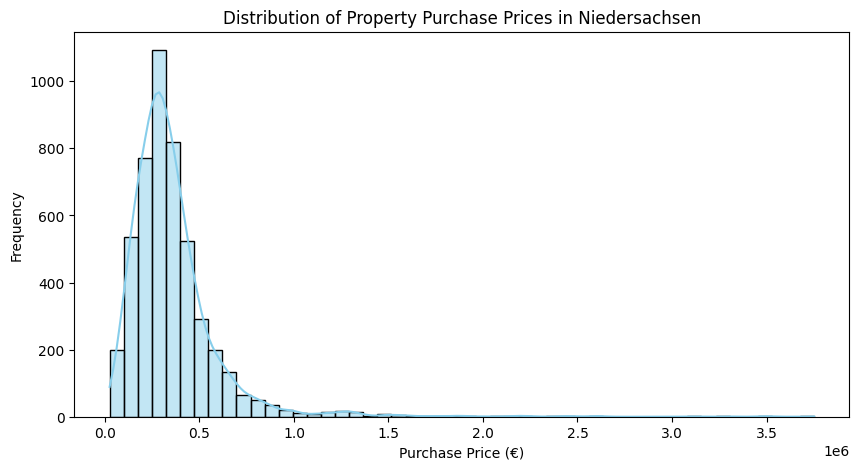

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# شحن البيانات
df = pd.read_csv('price_clean.csv')

# إعداد واجهة الرسم
plt.figure(figsize=(10, 5))

# رسم الـ Histogram مع منحنى الكثافة (KDE)
sns.histplot(df['obj_purchasePrice'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Property Purchase Prices in Niedersachsen')
plt.xlabel('Purchase Price (€)')
plt.ylabel('Frequency')

# إظهار الرسم
plt.show()

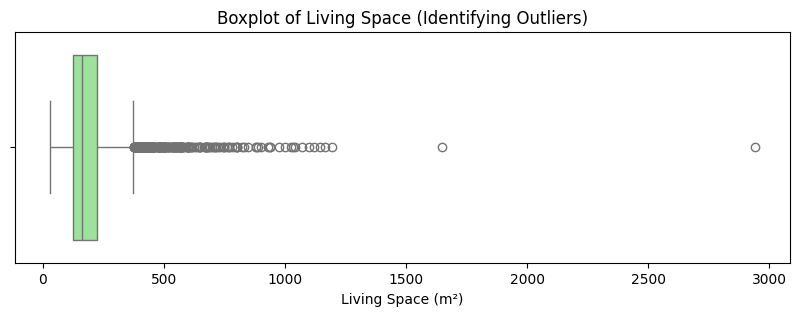

In [5]:
# رسم Boxplot للمساحة المعيشية
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['obj_livingSpace'], color='lightgreen')
plt.title('Boxplot of Living Space (Identifying Outliers)')
plt.xlabel('Living Space (m²)')
plt.show()

In [6]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"(Numerisch): {numerical_cols}\n")
print(f"(Nominal): {categorical_cols}")

(Numerisch): ['obj_yearConstructed', 'obj_livingSpace', 'geo_plz', 'obj_noRooms', 'obj_livingSpaceRange', 'obj_telekomUploadSpeed', 'obj_telekomDownloadSpeed', 'obj_purchasePrice', 'obj_purchasePrice_per_qm']

(Nominal): ['obj_regio1', 'obj_newlyConst', 'obj_firingTypes', 'obj_cellar', 'obj_houseNumber', 'geo_krs', 'obj_condition', 'obj_street', 'obj_telekomInternetProductAvailable', 'obj_barrierFree', 'obj_regio3']


C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_1640\240419728.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_1640\2901368446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='obj_condition', order=df['obj_condition'].value_counts().index, palette='viridis')


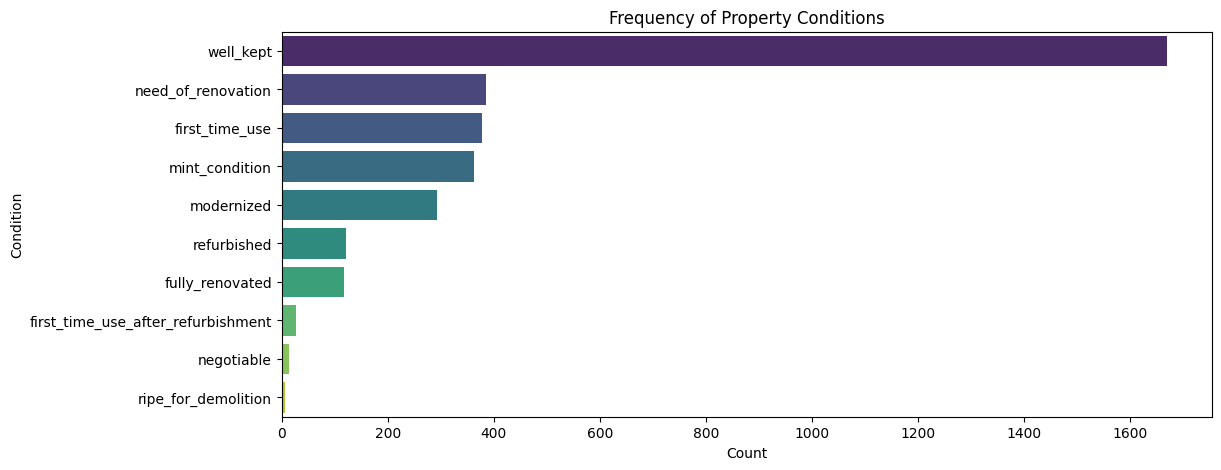

In [7]:
plt.figure(figsize=(12, 5))
# ترتيب الفئات تنازلياً لتسهيل القراءة
sns.countplot(data=df, y='obj_condition', order=df['obj_condition'].value_counts().index, palette='viridis')
plt.title('Frequency of Property Conditions')
plt.xlabel('Count')
plt.ylabel('Condition')
plt.show()

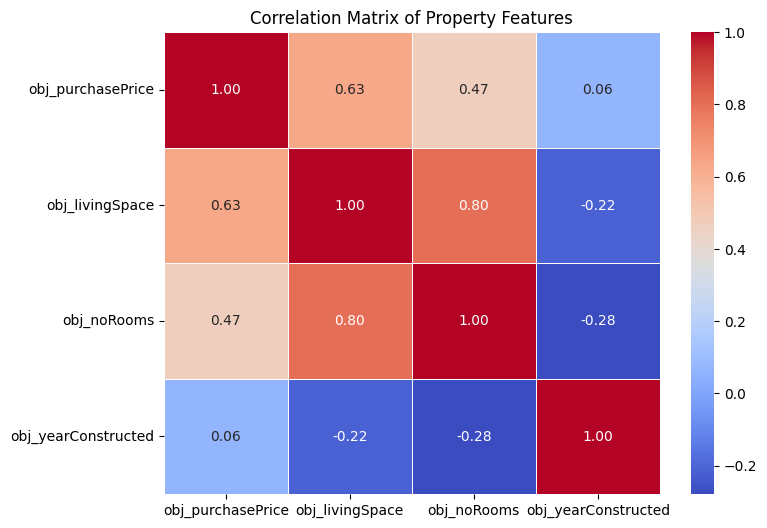

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. شحن البيانات
df = pd.read_csv('price_clean.csv')

# 2. اختيار المتغيرات الرقمية الأساسية لبحث الارتباط
numerical_features = ['obj_purchasePrice', 'obj_livingSpace', 'obj_noRooms', 'obj_yearConstructed']
corr_matrix = df[numerical_features].corr()

# 3. رسم الـ Heatmap بشكل أنيق
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Property Features')
plt.show()

In [9]:
import pandas as pd

# 1. شحن البيانات
df = pd.read_csv('price_clean.csv')

print("==================================================")
print("   1. GENUINE MISSING VALUES (NaN)                ")
print("==================================================")
# حساب عدد ونسبة القيم المفقودة الحقيقية (NaN)
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing_values, 'Percentage (%)': missing_percentage.round(2)})
# عرض الأعمدة التي تحتوي على NaN فقط
print(missing_df[missing_df['Missing Count'] > 0])


print("\n==================================================")
print("   2. HIDDEN MISSING VALUES ('no_information')    ")
print("==================================================")
# مصفوفة لتخزين النتائج وعرضها في جدول أنيق بدلاً من الـ loop التقليدي
hidden_data = []

for col in df.columns:
    # نقوم بتحويل العمود إلى نصوص مع استبدال القيم الفارغة بنص مؤقت لتجنب الأخطاء
    count = df[col].fillna('').astype(str).str.strip().eq('no_information').sum()
    if count > 0:
        pct = (count / len(df)) * 100
        hidden_data.append({'Column Name': col, 'Hidden Count': count, 'Percentage (%)': round(pct, 2)})

# تحويل النتائج إلى DataFrame لطباعتها بشكل جدول نظيف ومضمون
if hidden_data:
    hidden_df = pd.DataFrame(hidden_data).set_index('Column Name')
    print(hidden_df)
else:
    print("No hidden 'no_information' values found.")
    

   1. GENUINE MISSING VALUES (NaN)                
                                     Missing Count  Percentage (%)
obj_firingTypes                                740           15.30
obj_houseNumber                               4408           91.11
obj_condition                                 1464           30.26
obj_street                                    4408           91.11
obj_telekomInternetProductAvailable            301            6.22
obj_telekomUploadSpeed                         933           19.28
obj_telekomDownloadSpeed                       933           19.28

   2. HIDDEN MISSING VALUES ('no_information')    
No hidden 'no_information' values found.


  CORRELATION COEFFICIENTS WITH PURCHASE PRICE    
obj_livingSpace        0.631
obj_noRooms            0.468
obj_yearConstructed    0.061
dtype: float64
--------------------------------------------------



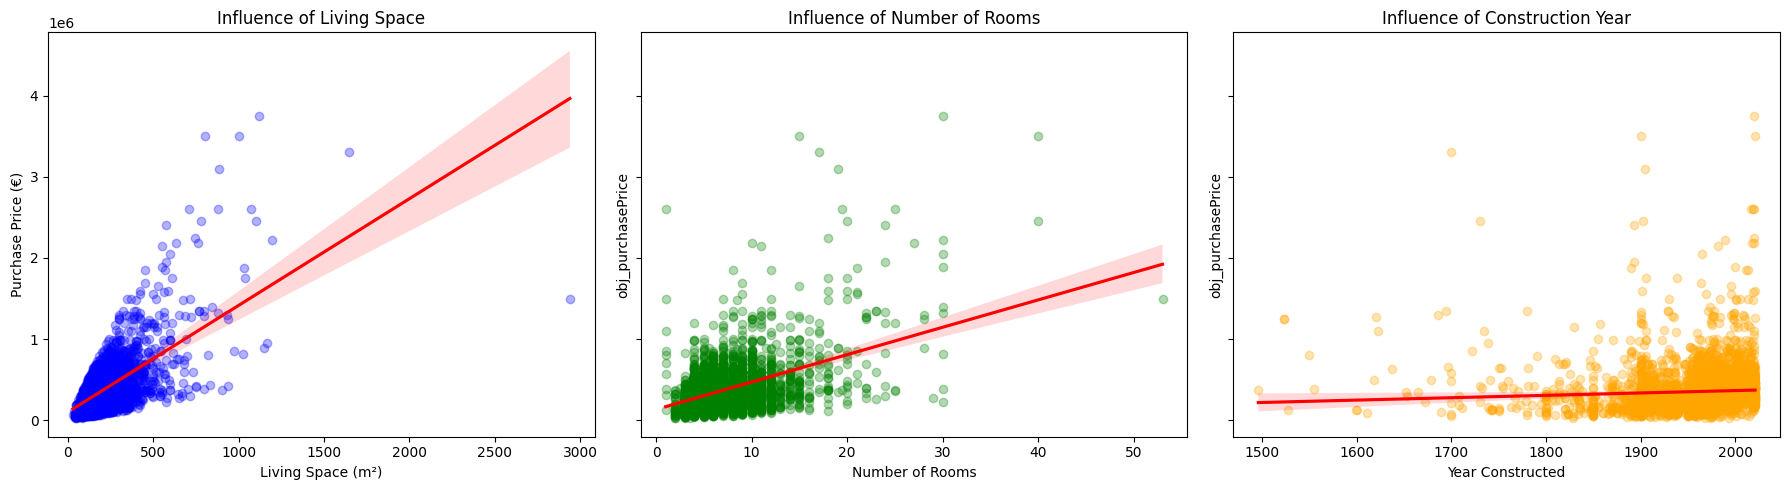

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. شحن البيانات
df = pd.read_csv('price_clean.csv')

# 2. حساب معاملات الارتباط (Pearson Correlation) مع السعر تحديداً
features = ['obj_livingSpace', 'obj_noRooms', 'obj_yearConstructed']
correlations = df[features].corrwith(df['obj_purchasePrice'])

print("==================================================")
print("  CORRELATION COEFFICIENTS WITH PURCHASE PRICE    ")
print("==================================================")
print(correlations.round(3))
print("--------------------------------------------------\n")

# 3. رسم تأثير كل متغير على السعر في لوحة واحدة (Subplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# أ. تأثير المساحة المعيشية
sns.regplot(ax=axes[0], data=df, x='obj_livingSpace', y='obj_purchasePrice', 
            scatter_kws={'alpha':0.3, 'color':'blue'}, line_kws={'color':'red'})
axes[0].set_title('Influence of Living Space')
axes[0].set_xlabel('Living Space (m²)')
axes[0].set_ylabel('Purchase Price (€)')

# ب. تأثير عدد الغرف
sns.regplot(ax=axes[1], data=df, x='obj_noRooms', y='obj_purchasePrice', 
            scatter_kws={'alpha':0.3, 'color':'green'}, line_kws={'color':'red'})
axes[1].set_title('Influence of Number of Rooms')
axes[1].set_xlabel('Number of Rooms')

# ج. تأثير سنة البناء
sns.regplot(ax=axes[2], data=df, x='obj_yearConstructed', y='obj_purchasePrice', 
            scatter_kws={'alpha':0.3, 'color':'orange'}, line_kws={'color':'red'})
axes[2].set_title('Influence of Construction Year')
axes[2].set_xlabel('Year Constructed')

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

# شحن البيانات
df = pd.read_csv('price_clean.csv')

print("==================================================")
print("  INFLUENCE OF INTERNET SPEED ON PURCHASE PRICE   ")
print("==================================================")
# تقسيم سرعات التحميل إلى فئات لمعرفة تأثيرها على متوسط السعر
df['internet_group'] = pd.cut(df['obj_telekomDownloadSpeed'], 
                              bins=[0, 50, 250, 1000], 
                              labels=['Slow (<50 Mbps)', 'Medium (50-250 Mbps)', 'SuperFast (up to 1000 Mbps)'])

print(df.groupby('internet_group')['obj_purchasePrice'].mean().round(2))


print("\n==================================================")
print("  TOP 5 MOST EXPENSIVE POSTCODES (PLz)            ")
print("==================================================")
# معرفة أغلى 5 رموز بريدية من حيث متوسط سعر المتر المربع
top_plz = df.groupby('geo_plz')['obj_purchasePrice_per_qm'].mean().round(2).sort_values(ascending=False).head(5)
print(top_plz)

  INFLUENCE OF INTERNET SPEED ON PURCHASE PRICE   
internet_group
Slow (<50 Mbps)         346960.34
Medium (50-250 Mbps)    371936.21
Name: obj_purchasePrice, dtype: float64

  TOP 5 MOST EXPENSIVE POSTCODES (PLz)            
geo_plz
38118.0    4250.00
30659.0    4234.57
31608.0    4149.37
21228.0    3982.30
21271.0    3887.72
Name: obj_purchasePrice_per_qm, dtype: float64


In [12]:
import pandas as pd

# 1. شحن البيانات
df = pd.read_csv('price_clean.csv')

# 2. تحديد الأعمدة الاسمية (Categorical/Nominal)
categorical_cols = [
    'obj_regio1', 'obj_newlyConst', 'obj_cellar', 'obj_condition', 
    'obj_firingTypes', 'obj_telekomInternetProductAvailable', 'obj_barrierFree'
]

print("==================================================")
print("  NOMINAL VARIABLES ANALYSIS (Distribution & Price)")
print("==================================================")

for col in categorical_cols:
    if col in df.columns:
        print(f"\n>>> Analyzing Column: {col} <<<")
        print("-" * 40)
        
        # حساب التكرار والنسبة المئوية لكل فئة
        counts = df[col].value_counts()
        percentages = df[col].value_counts(normalize=True) * 100
        
        # حساب متوسط السعر لكل فئة
        mean_price = df.groupby(col)['obj_purchasePrice'].mean()
        
        # دمج النتائج في جدول واحد أنيق للعمود
        summary_table = pd.DataFrame({
            'Count': counts,
            'Percentage (%)': percentages.round(2),
            'Mean Purchase Price (€)': mean_price.round(2)
        })
        
        print(summary_table)
        print("=" * 50)

  NOMINAL VARIABLES ANALYSIS (Distribution & Price)

>>> Analyzing Column: obj_regio1 <<<
----------------------------------------
               Count  Percentage (%)  Mean Purchase Price (€)
obj_regio1                                                   
Niedersachsen   4838           100.0                356673.25

>>> Analyzing Column: obj_newlyConst <<<
----------------------------------------
                Count  Percentage (%)  Mean Purchase Price (€)
obj_newlyConst                                                
n                4271           88.28                352894.89
y                 567           11.72                385134.23

>>> Analyzing Column: obj_cellar <<<
----------------------------------------
            Count  Percentage (%)  Mean Purchase Price (€)
obj_cellar                                                
n            3084           63.75                360880.94
y            1754           36.25                349275.02

>>> Analyzing Column: obj_condit

In [13]:
import pandas as pd

# شحن البيانات
df = pd.read_csv('price_clean.csv')

# بناء جدول فحص شامل لكل الأعمدة العشرين
data_inventory = pd.DataFrame({
    'Data Type (النوع البرمجي)': df.dtypes,
    'Missing Values (NaN)': df.isnull().sum(),
    'Unique Values (القيم الفريدة)': df.nunique()
})

print("================================================================")
print("   COMPLETE 20-COLUMN DATA INVENTORY (المسح الشامل للداتا)   ")
print("================================================================")
print(data_inventory)

   COMPLETE 20-COLUMN DATA INVENTORY (المسح الشامل للداتا)   
                                    Data Type (النوع البرمجي)  \
obj_regio1                                                str   
obj_newlyConst                                            str   
obj_yearConstructed                                   float64   
obj_firingTypes                                           str   
obj_cellar                                                str   
obj_houseNumber                                           str   
obj_livingSpace                                       float64   
geo_krs                                                   str   
obj_condition                                             str   
obj_street                                                str   
geo_plz                                               float64   
obj_noRooms                                           float64   
obj_telekomInternetProductAvailable                    object   
obj_barrierFree             

--- 🔗 جدول ارتباط الأعمدة الرقمية بعمود السعر Target ---
                          Pearson (Linear)  Spearman (Rank)
geo_plz                          -0.032617        -0.075197
obj_livingSpace                   0.631197         0.496689
obj_livingSpaceRange              0.451615         0.490814
obj_noRooms                       0.468424         0.289894
obj_purchasePrice                 1.000000         1.000000
obj_purchasePrice_per_qm          0.471710         0.616479
obj_telekomDownloadSpeed          0.055874         0.051078
obj_telekomUploadSpeed            0.053277         0.052941
obj_yearConstructed               0.061064         0.285609


<function matplotlib.pyplot.show(close=None, block=None)>

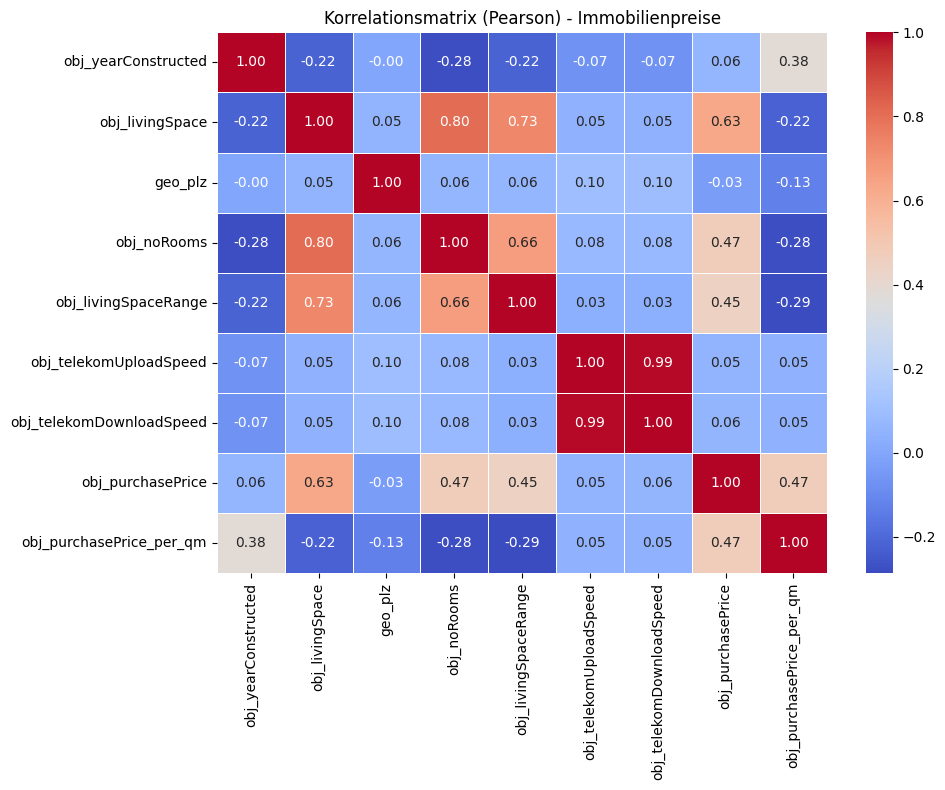

In [14]:
pearson_corr = df[numerical_cols].corr(method='pearson')['obj_purchasePrice'].sort_values(ascending=False)
spearman_corr = df[numerical_cols].corr(method='spearman')['obj_purchasePrice'].sort_values(ascending=False)
correlation_summary = pd.DataFrame({
    'Pearson (Linear)' : pearson_corr,
    'Spearman (Rank)' :spearman_corr
})
print("--- 🔗 جدول ارتباط الأعمدة الرقمية بعمود السعر Target ---")
print(correlation_summary)

plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(method='pearson'), annot=True ,cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korrelationsmatrix (Pearson) - Immobilienpreise')
plt.tight_layout()
plt.show

C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_1640\1922206320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_correlations.values, y=price_correlations.index, palette='coolwarm')


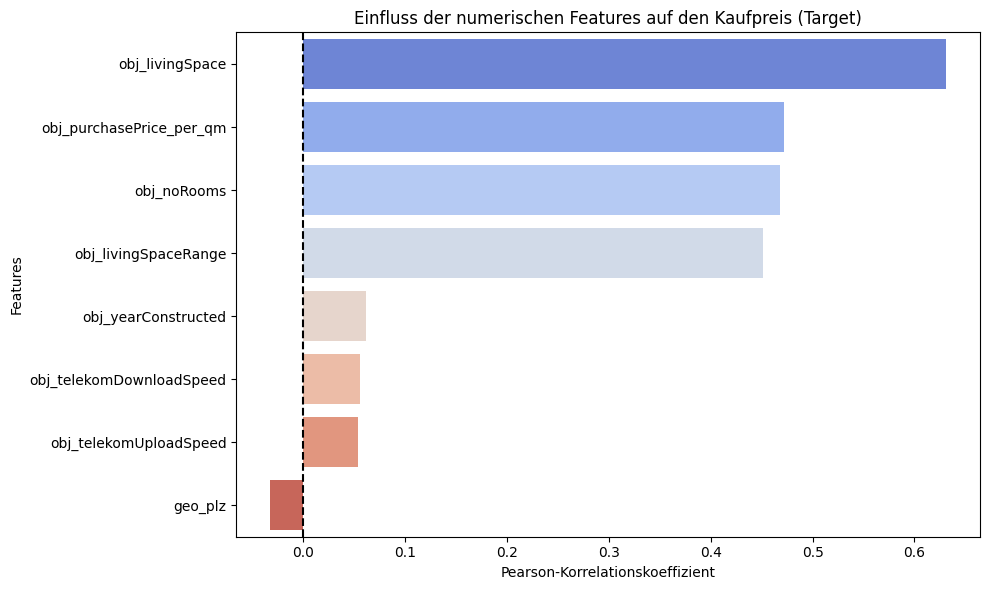

In [15]:
# 1. عزل ارتباط الأعمدة مع السعر فقط وحذف ارتباط السعر مع نفسه
price_correlations = df[numerical_cols].corr(method='pearson')['obj_purchasePrice'].drop('obj_purchasePrice').sort_values(ascending=False)

# 2. رسم المخطط العمودي
plt.figure(figsize=(10, 6))
sns.barplot(x=price_correlations.values, y=price_correlations.index, palette='coolwarm')
plt.axvline(x=0, color='black', linestyle='--') # خط مرجعي عند الصفر
plt.title('Einfluss der numerischen Features auf den Kaufpreis (Target)')
plt.xlabel('Pearson-Korrelationskoeffizient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

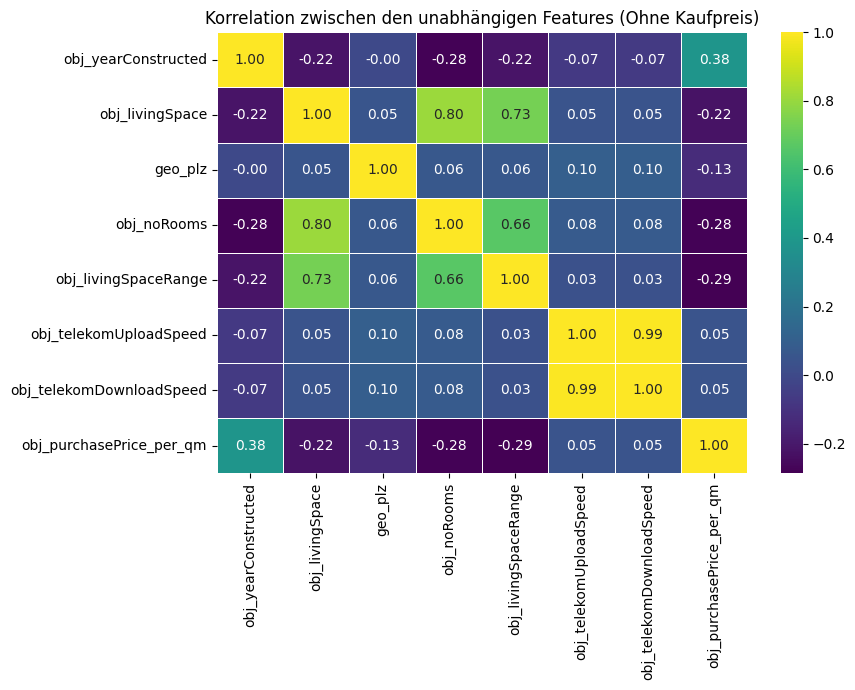

In [16]:
# 1. إنشاء قائمة بالأعمدة الرقمية بدون عمود السعر
features_only = [col for col in numerical_cols if col != 'obj_purchasePrice']

# 2. حساب مصفوفة الارتباط للميزات فقط
features_corr = df[features_only].corr(method='pearson')

# 3. رسم الخارطة الحرارية للعلاقات بين الميزات
plt.figure(figsize=(9, 7))
sns.heatmap(features_corr, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('Korrelation zwischen den unabhängigen Features (Ohne Kaufpreis)')
plt.tight_layout()
plt.show()

### 1. Analysis of Property Condition (obj_condition)

C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_1640\1113454259.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


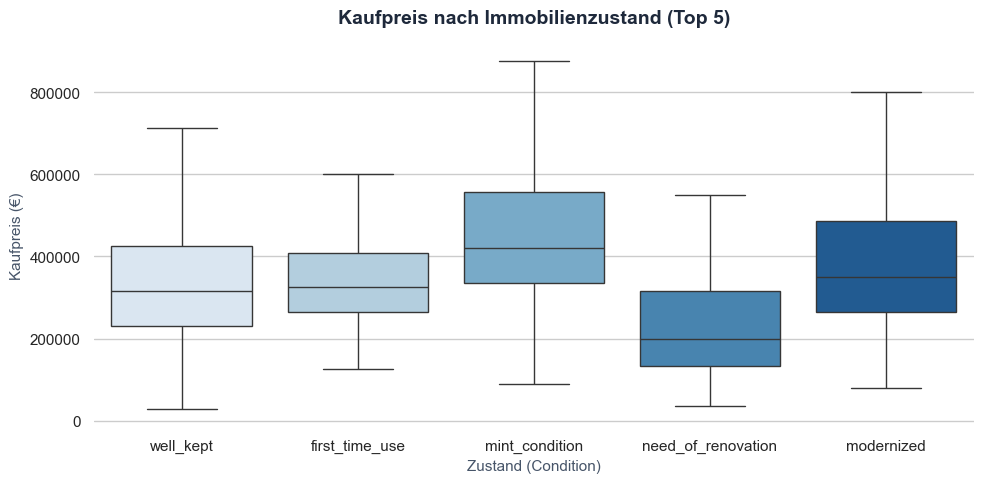

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إعداد اللوحة بخلفية بيضاء ونظيفة
plt.figure(figsize=(10, 5), dpi=100)
sns.set_theme(style="whitegrid")

# 2. رسم البوكس بلوت لأعلى 5 فئات مكررة وبدون القيم الشاذة المتطرفة
top_frequent = df['obj_condition'].value_counts().head(5).index

sns.boxplot(
    data=df[df['obj_condition'].isin(top_frequent)], 
    x='obj_condition', 
    y='obj_purchasePrice', 
    palette='Blues', 
    showfliers=False
)

# ⭐ 3. السطر السحري لتوحيد المحور وعرض الأرقام كاملة وصريحة (مثل 200000)
plt.ticklabel_format(style='plain', axis='y')

# 4. العناوين الأنيقة والمحاور
plt.title('Kaufpreis nach Immobilienzustand (Top 5)', fontsize=14, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel('Zustand (Condition)', fontsize=11, color='#475569')
plt.ylabel('Kaufpreis (€)', fontsize=11, color='#475569')

sns.despine(left=True, bottom=True) # حذف الإطار الخارجي لشكل عصري
plt.tight_layout()
plt.show()

### 2. Analysis of Heating Types (obj_firingTypes)

C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_1640\483463966.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


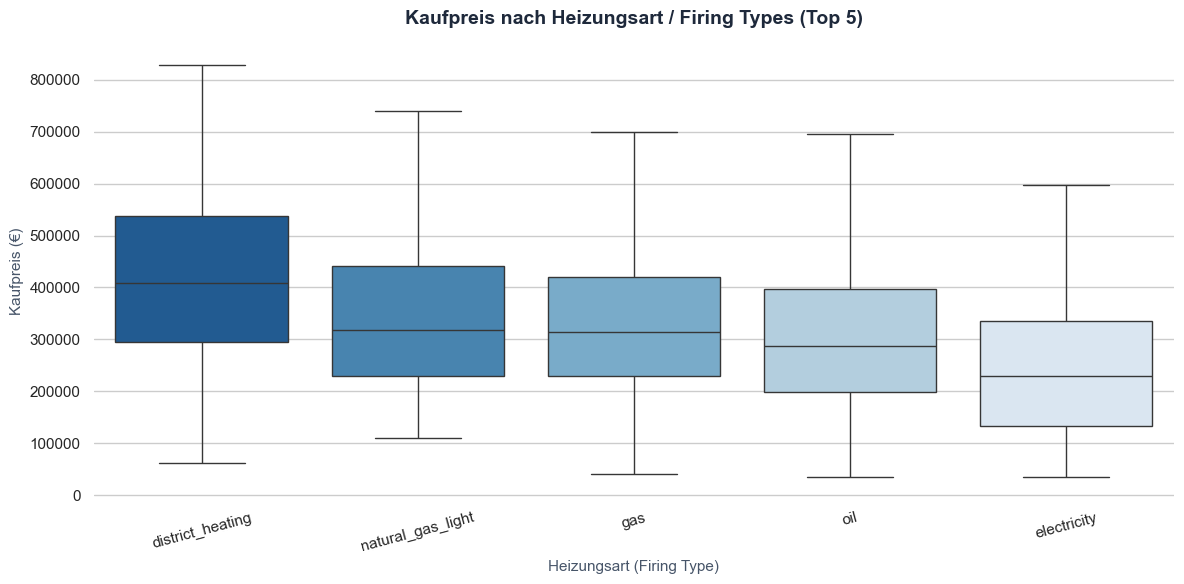

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6), dpi=100)
sns.set_theme(style="whitegrid")

top_firing = df['obj_firingTypes'].value_counts().head(5).index

# الخطوة السحرية: تصفية البيانات ثم ترتيب الفئات بناءً على "وسيط السعر" تنازلياً
# لكي تظهر الفئة الأغلى في أول الرسمة على اليسار
ordered_firing = (
    df[df['obj_firingTypes'].isin(top_firing)]
    .groupby('obj_firingTypes')['obj_purchasePrice']
    .median()
    .sort_values(ascending=False)
    .index
)

# 3. رسم البوكس بلوت مع تطبيق الترتيب الجديد وعكس الألوان (_r)
sns.boxplot(
    data=df[df['obj_firingTypes'].isin(top_firing)], 
    x='obj_firingTypes', 
    y='obj_purchasePrice', 
    order=ordered_firing,  # إجبار بايثون على هذا الترتيب السعري
    palette='Blues_r',     # حرف _r يعني المعكوس (الأغمق للأغلى والأفتح للأرخص)
    showfliers=False
)

# 4. توحيد المحور الصادي لإظهار الأرقام صريحة (مثل 200000)
plt.ticklabel_format(style='plain', axis='y')

# 5. العناوين الأنيقة والمحاور (بالألمانية والانكليزية)
plt.title('Kaufpreis nach Heizungsart / Firing Types (Top 5)', fontsize=14, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel('Heizungsart (Firing Type)', fontsize=11, color='#475569')
plt.ylabel('Kaufpreis (€)', fontsize=11, color='#475569')

# تدوير أسماء الفئات قليلاً لكي لا تتداخل الكلمات إذا كانت طويلة
plt.xticks(rotation=15)

sns.despine(left=True, bottom=True) # حذف الإطار الخارجي لشكل عصري
plt.tight_layout()
plt.show()

### 3. Analysis of Cities (obj_regio2)

C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_1640\1444600398.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


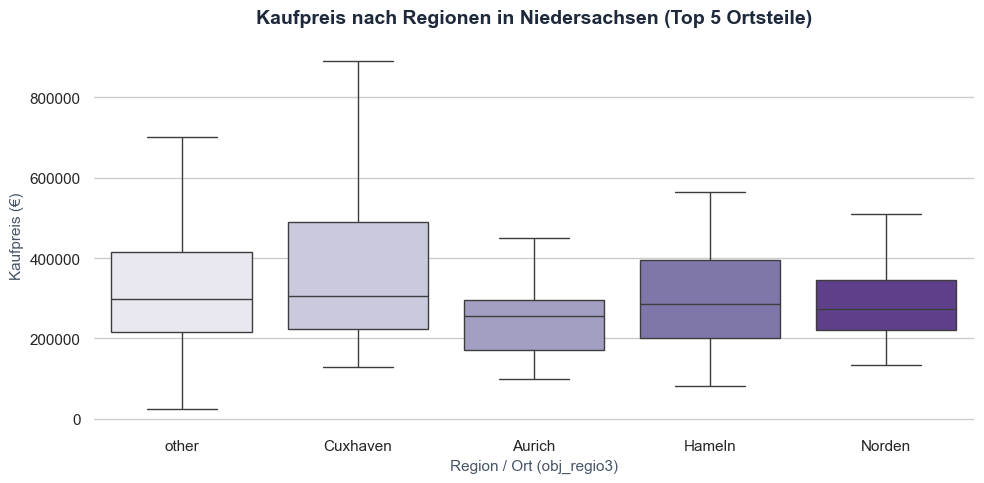

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إعداد اللوحة بخلفية بيضاء ونظيفة
plt.figure(figsize=(10, 5), dpi=100)
sns.set_theme(style="whitegrid")

# 2. فلترة أعلى 5 مناطق (obj_regio3) تحتوي على أكثر عدد عقارات
top_regions = df['obj_regio3'].value_counts().head(5).index

# 3. رسم البوكس بلوت للأحياء الخمسة الأكبر
sns.boxplot(
    data=df[df['obj_regio3'].isin(top_regions)], 
    x='obj_regio3', 
    y='obj_purchasePrice', 
    palette='Purples', # اللون البنفسجي الملكي الأنيق
    showfliers=False
)

# 4. التنسيق والعناوين باللغة الألمانية
plt.title('Kaufpreis nach Regionen in Niedersachsen (Top 5 Ortsteile)', fontsize=14, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel('Region / Ort (obj_regio3)', fontsize=11, color='#475569')
plt.ylabel('Kaufpreis (€)', fontsize=11, color='#475569')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_1640\1329981077.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


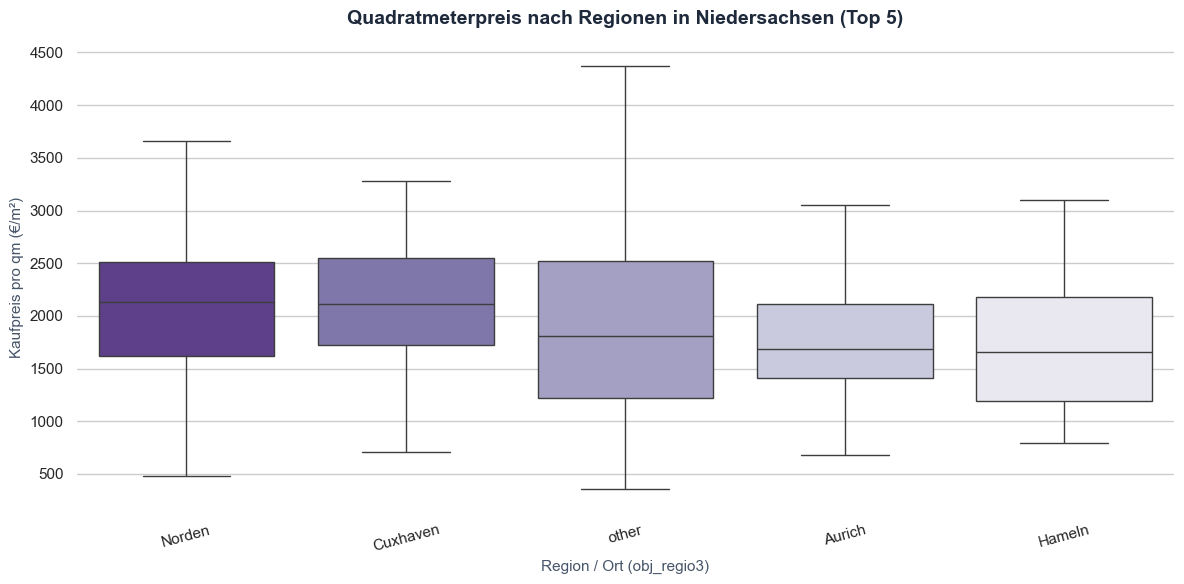

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إعداد اللوحة بخلفية بيضاء ونظيفة
plt.figure(figsize=(12, 6), dpi=100)
sns.set_theme(style="whitegrid")

# 2. فلترة أعلى 5 مناطق (obj_regio3) تحتوي على أكثر عدد عقارات
top_regions = df['obj_regio3'].value_counts().head(5).index

# ⭐ خطوة ذكية: ترتيب المناطق بناءً على "وسيط سعر المتر المربع" تنازلياً
# لكي تظهر المنطقة الأغلى على اليسار باللون الأغمق
ordered_regions = (
    df[df['obj_regio3'].isin(top_regions)]
    .groupby('obj_regio3')['obj_purchasePrice_per_qm']
    .median()
    .sort_values(ascending=False)
    .index
)

# 3. رسم البوكس بلوت لمقارنة سعر المتر المربع (obj_purchasePrice_per_qm)
sns.boxplot(
    data=df[df['obj_regio3'].isin(top_regions)], 
    x='obj_regio3', 
    y='obj_purchasePrice_per_qm',  # التعديل الأساسي هنا
    order=ordered_regions,          # تطبيق الترتيب السعري الذكي
    palette='Purples_r',           # التدرج الملكي المعكوس (الأغمق للأغلى)
    showfliers=False
)

# 4. توحيد المحور الصادي لإظهار الأرقام صريحة وبسيطة
plt.ticklabel_format(style='plain', axis='y')

# 5. التنسيق والعناوين المحدثة باللغة الألمانية والإنجليزية
plt.title('Quadratmeterpreis nach Regionen in Niedersachsen (Top 5)', fontsize=14, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel('Region / Ort (obj_regio3)', fontsize=11, color='#475569')
plt.ylabel('Kaufpreis pro qm (€/m²)', fontsize=11, color='#475569')

# تدوير أسماء المدن قليلاً لضمان عدم التداخل البصري
plt.xticks(rotation=15)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Value Counts Heatmap

In [21]:
# طباعة ملخص سريع لجميع الأعمدة التصنيفية المتبقية لمعرفة عدد الفئات (Unique Values) في كل منها
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("--- Zusammenfassung der nominalen Features ---")
for col in categorical_cols:
    print(f"Feature: {col} | Anzahl eindeutiger Werte (Unique): {df[col].nunique()}")
    print(df[col].value_counts().head(3)) # طباعة أعلى 3 فئات تكراراً فقط للاختصار
    print("-" * 50)

--- Zusammenfassung der nominalen Features ---
Feature: obj_regio1 | Anzahl eindeutiger Werte (Unique): 1
obj_regio1
Niedersachsen    4838
Name: count, dtype: int64
--------------------------------------------------
Feature: obj_newlyConst | Anzahl eindeutiger Werte (Unique): 2
obj_newlyConst
n    4271
y     567
Name: count, dtype: int64
--------------------------------------------------
Feature: obj_firingTypes | Anzahl eindeutiger Werte (Unique): 57
obj_firingTypes
gas            2665
oil             791
electricity     124
Name: count, dtype: int64
--------------------------------------------------
Feature: obj_cellar | Anzahl eindeutiger Werte (Unique): 2
obj_cellar
n    3084
y    1754
Name: count, dtype: int64
--------------------------------------------------
Feature: obj_houseNumber | Anzahl eindeutiger Werte (Unique): 120
obj_houseNumber
X    68
2    23
1    19
Name: count, dtype: int64
--------------------------------------------------
Feature: geo_krs | Anzahl eindeutiger Wer

C:\Users\Yasser Nourallah\AppData\Local\Temp\ipykernel_1640\3921913783.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns
